c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\shrin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


📏 Silhouette Score (UMAP): 0.4152


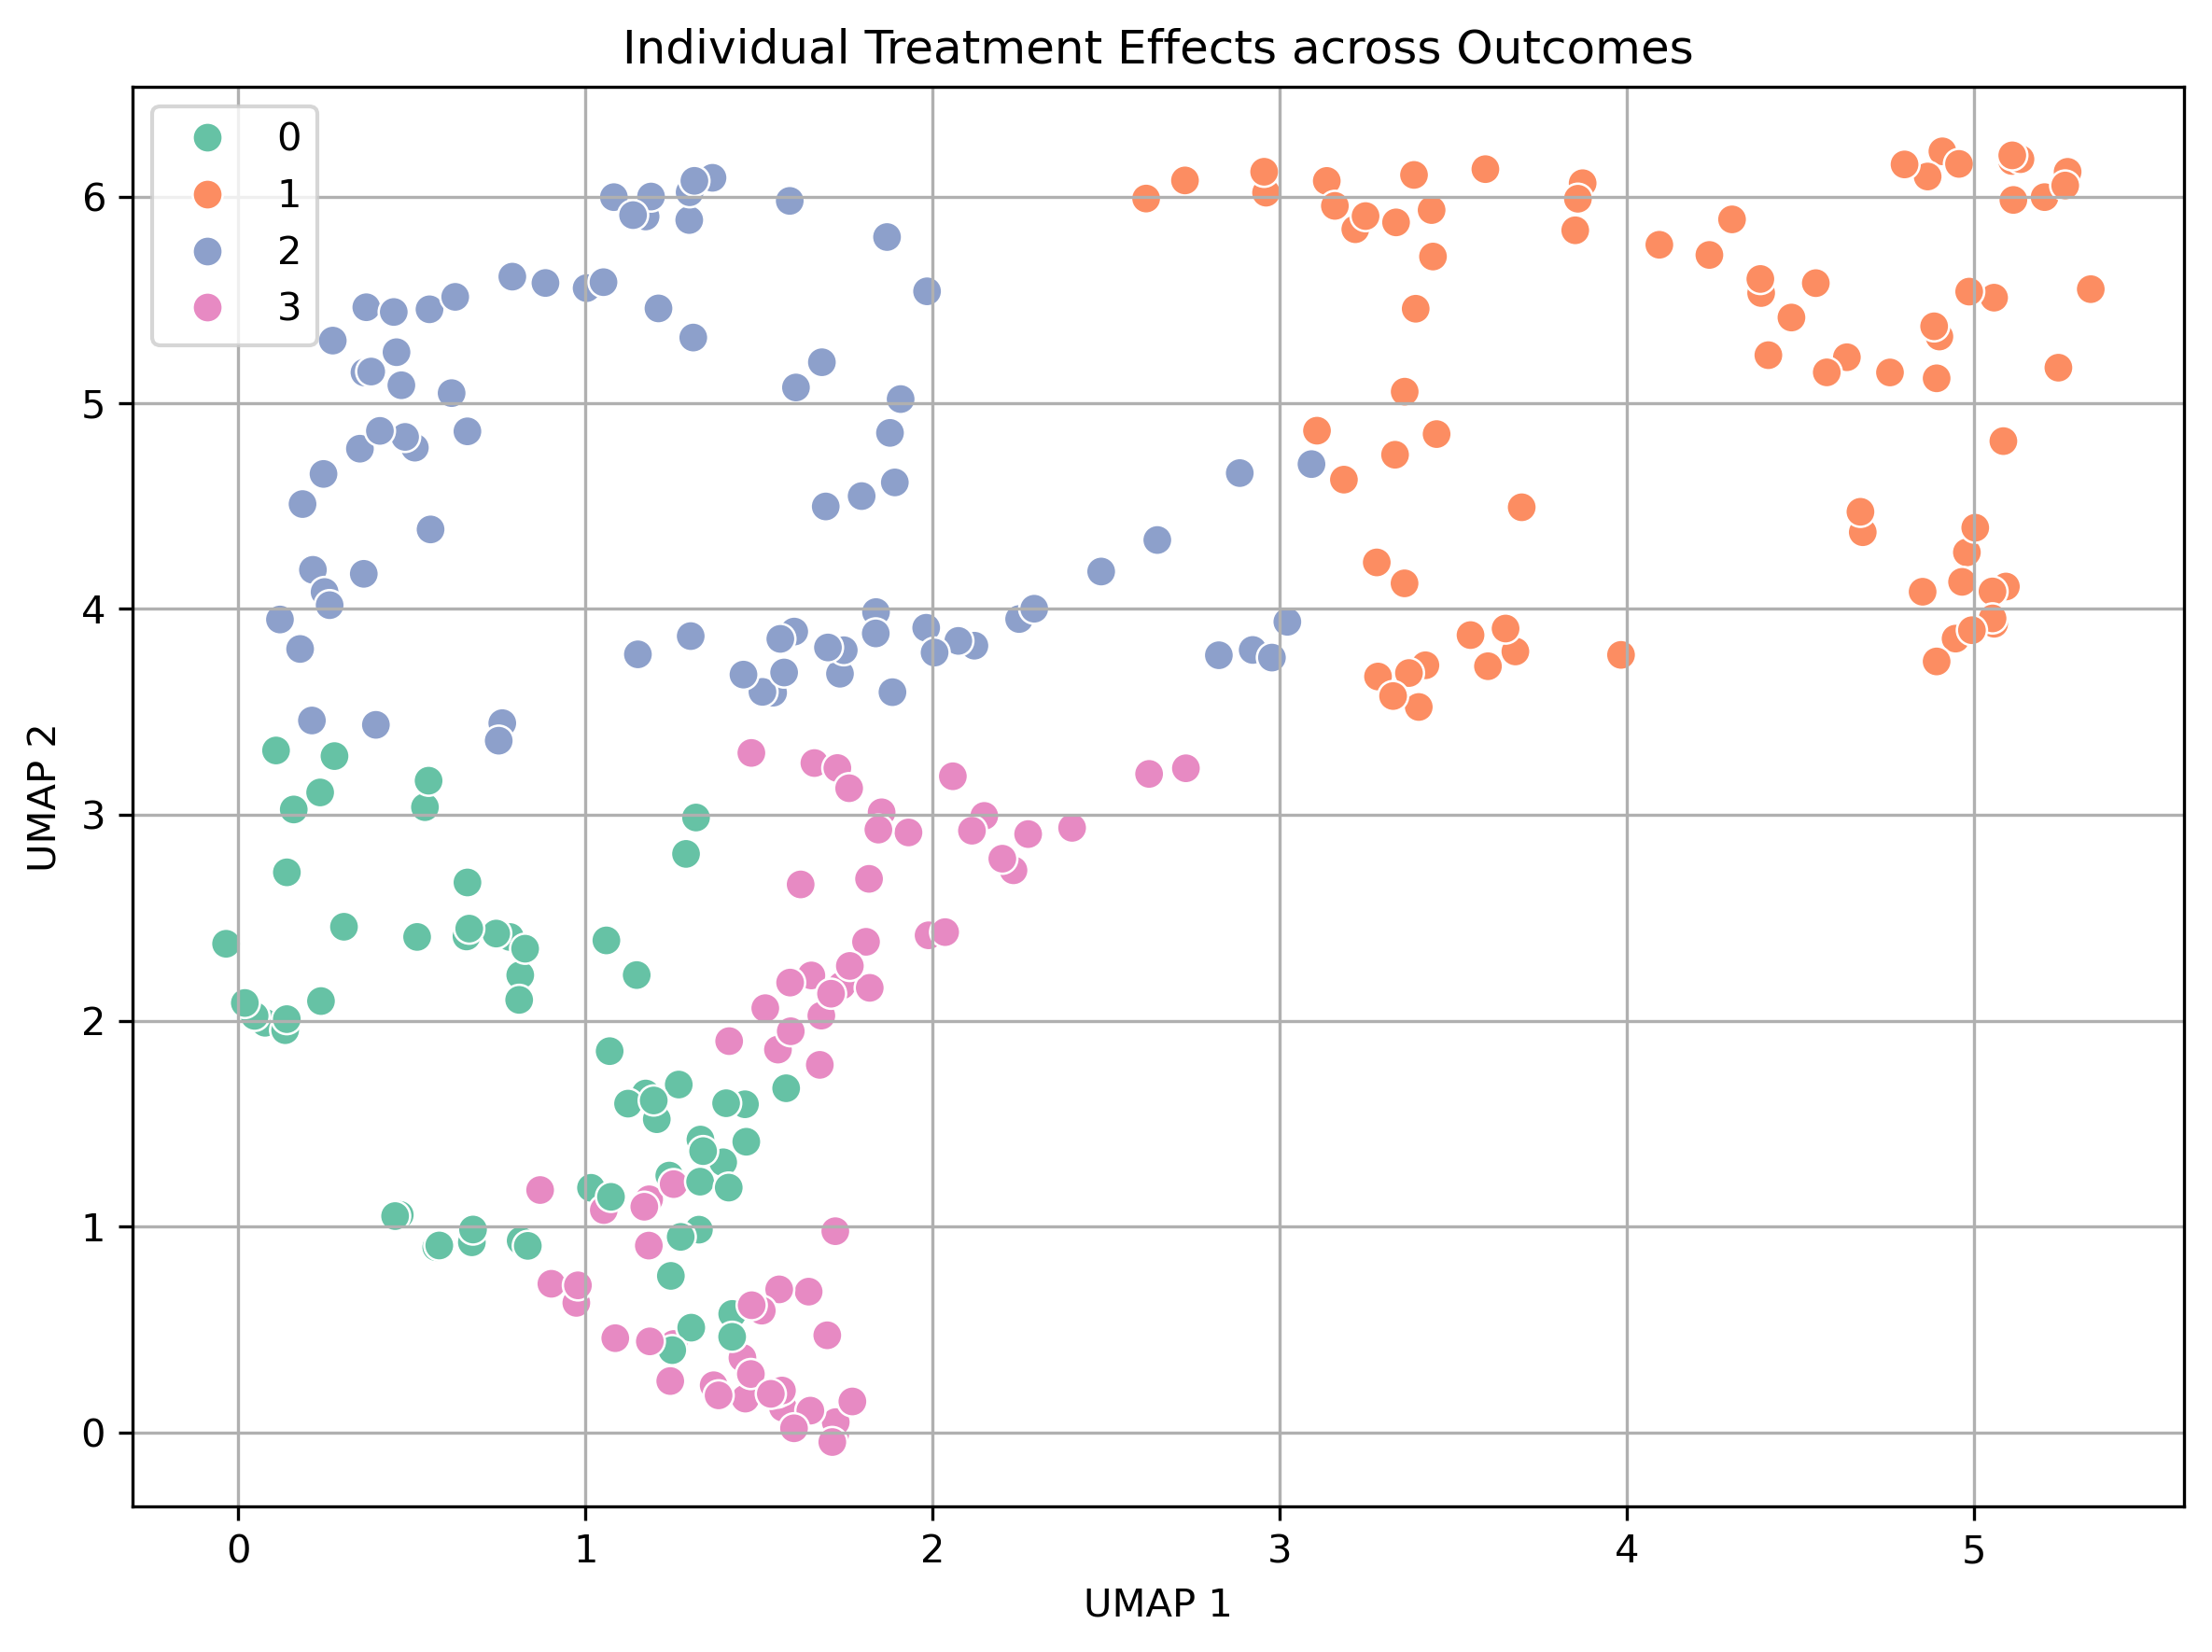

In [1]:
from modules.cluster import generate_cate_matrix, umap_cluster_cates, visualize_clusters, visualize_clusters_3d_plotly, plot_cate_tradeoff
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from modules.preprocess import load_and_clean_data, prepare_variables



# Step 1: prepare baseline
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, outcome_col='vs_clin')  # any outcome will do, X is same

# Step 2: define CATE sources
cate_file_dict = {
    "mrs_binary": "cate_results/cate_results_mrs_binary.csv",
    "infarct_dch": "cate_results/cate_results_infarct_dch.csv",
    "vs_clin": "cate_results/cate_results_vs_clin.csv",
    "infection_dch": "cate_results/cate_results_infection_dch.csv",
    "gos_binary": "cate_results/cate_results_gos_binary.csv",
    "shunt_180": "cate_results/cate_results_shunt_180.csv",
}

# Step 3: build matrix
cate_matrix = generate_cate_matrix(X, cate_file_dict)


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

import matplotlib.pyplot as plt
import seaborn as sns



# Step 4: UMAP-based cluster
X_umap, clusters, reducer, kmeans = umap_cluster_cates(cate_matrix, n_clusters=4)
# Step 5: Visualize
visualize_clusters(X_umap, clusters, method="UMAP")


In [2]:
visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=None , method="UMAP")

c:\Users\shrin\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [3]:
fig = visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=kmeans, method="UMAP")

# 🧹 Strip unsafe template
fig.layout.template = "none"

# ✅ Save clean figure
import plotly.io as pio
pio.write_json(fig, "clusters/umap_plot.json", pretty=True)


In [4]:
from joblib import dump



# Save UMAP + KMeans
dump(X_umap, "clusters/umap_embedding.joblib")
dump(clusters, "clusters/umap_clusters.joblib")
dump(reducer, "clusters/umap_model.joblib")         
dump(kmeans, "clusters/kmeans_model.joblib")       


['clusters/kmeans_model.joblib']

In [11]:
import pandas as pd
df_clustered = pd.DataFrame(X, columns=feature_names)
df_clustered['cluster'] = clusters

# Compare means across clusters
cluster_summary = df_clustered.groupby('cluster').mean()
# Add standard deviation for each feature per cluster
cluster_sd = df_clustered.groupby('cluster').std()
cluster_summary_sd = cluster_summary.copy()
for col in cluster_sd.columns:
    cluster_summary_sd[col + '_sd'] = cluster_sd[col]

# For HH (assuming 'HH' is a categorical variable in df_clustered)
if 'HH' in df_clustered.columns:
    hh_breakdown = df_clustered.groupby('cluster')['HH'].value_counts().unstack(fill_value=0)
    print("HH breakdown per cluster:")
    print(hh_breakdown)

# For BMI, add SD
if 'bmi' in df_clustered.columns:
    cluster_summary_sd['bmi_sd'] = df_clustered.groupby('cluster')['bmi'].std()

print(cluster_summary_sd)
print(cluster_summary)


               age        hh    ct_ivh    ct_ich       sex  aneurysm_trt  \
cluster                                                                    
0        52.032787  2.475410  0.459016  0.196721  0.311475      0.606557   
1        59.141026  3.333333  0.756410  0.538462  0.333333      0.333333   
2        60.864198  3.382716  0.728395  0.419753  0.320988      0.518519   
3        47.880597  2.462687  0.432836  0.268657  0.283582      0.626866   

         aneurysm_circulation   mrs_adm  aneurysm_size  aneurysm_no  ...  \
cluster                                                              ...   
0                    0.819672  0.983607       6.956991     1.327869  ...   
1                    0.910256  0.910256       6.764768     1.487179  ...   
2                    0.777778  0.901235       7.257014     1.493827  ...   
3                    0.880597  0.970149       7.364798     1.238806  ...   

            bmi_sd  rr_map_mean_sd  rr_syst_mean_sd  rr_dia_mean_sd  \
cluster        

In [12]:
cluster_summary.to_csv("clusters/cluster_feature_means.csv")

In [13]:
cate_df = pd.DataFrame(cate_matrix, columns=list(cate_file_dict.keys()))
cate_df['cluster'] = clusters

# Mean CATEs per cluster
print(cate_df.groupby('cluster').mean())


         mrs_binary  infarct_dch   vs_clin  infection_dch  gos_binary  \
cluster                                                                 
0          0.049257     0.085986 -0.090752       0.060469    0.085986   
1         -0.018275    -0.021115 -0.084469      -0.002461   -0.021115   
2         -0.004186     0.062205 -0.142326      -0.003977    0.062205   
3          0.031796     0.081916 -0.054314       0.038708    0.081916   

         shunt_180  
cluster             
0         0.052213  
1         0.098821  
2         0.050047  
3         0.131148  


In [14]:
cate_df.columns

Index(['mrs_binary', 'infarct_dch', 'vs_clin', 'infection_dch', 'gos_binary',
       'shunt_180', 'cluster'],
      dtype='object')

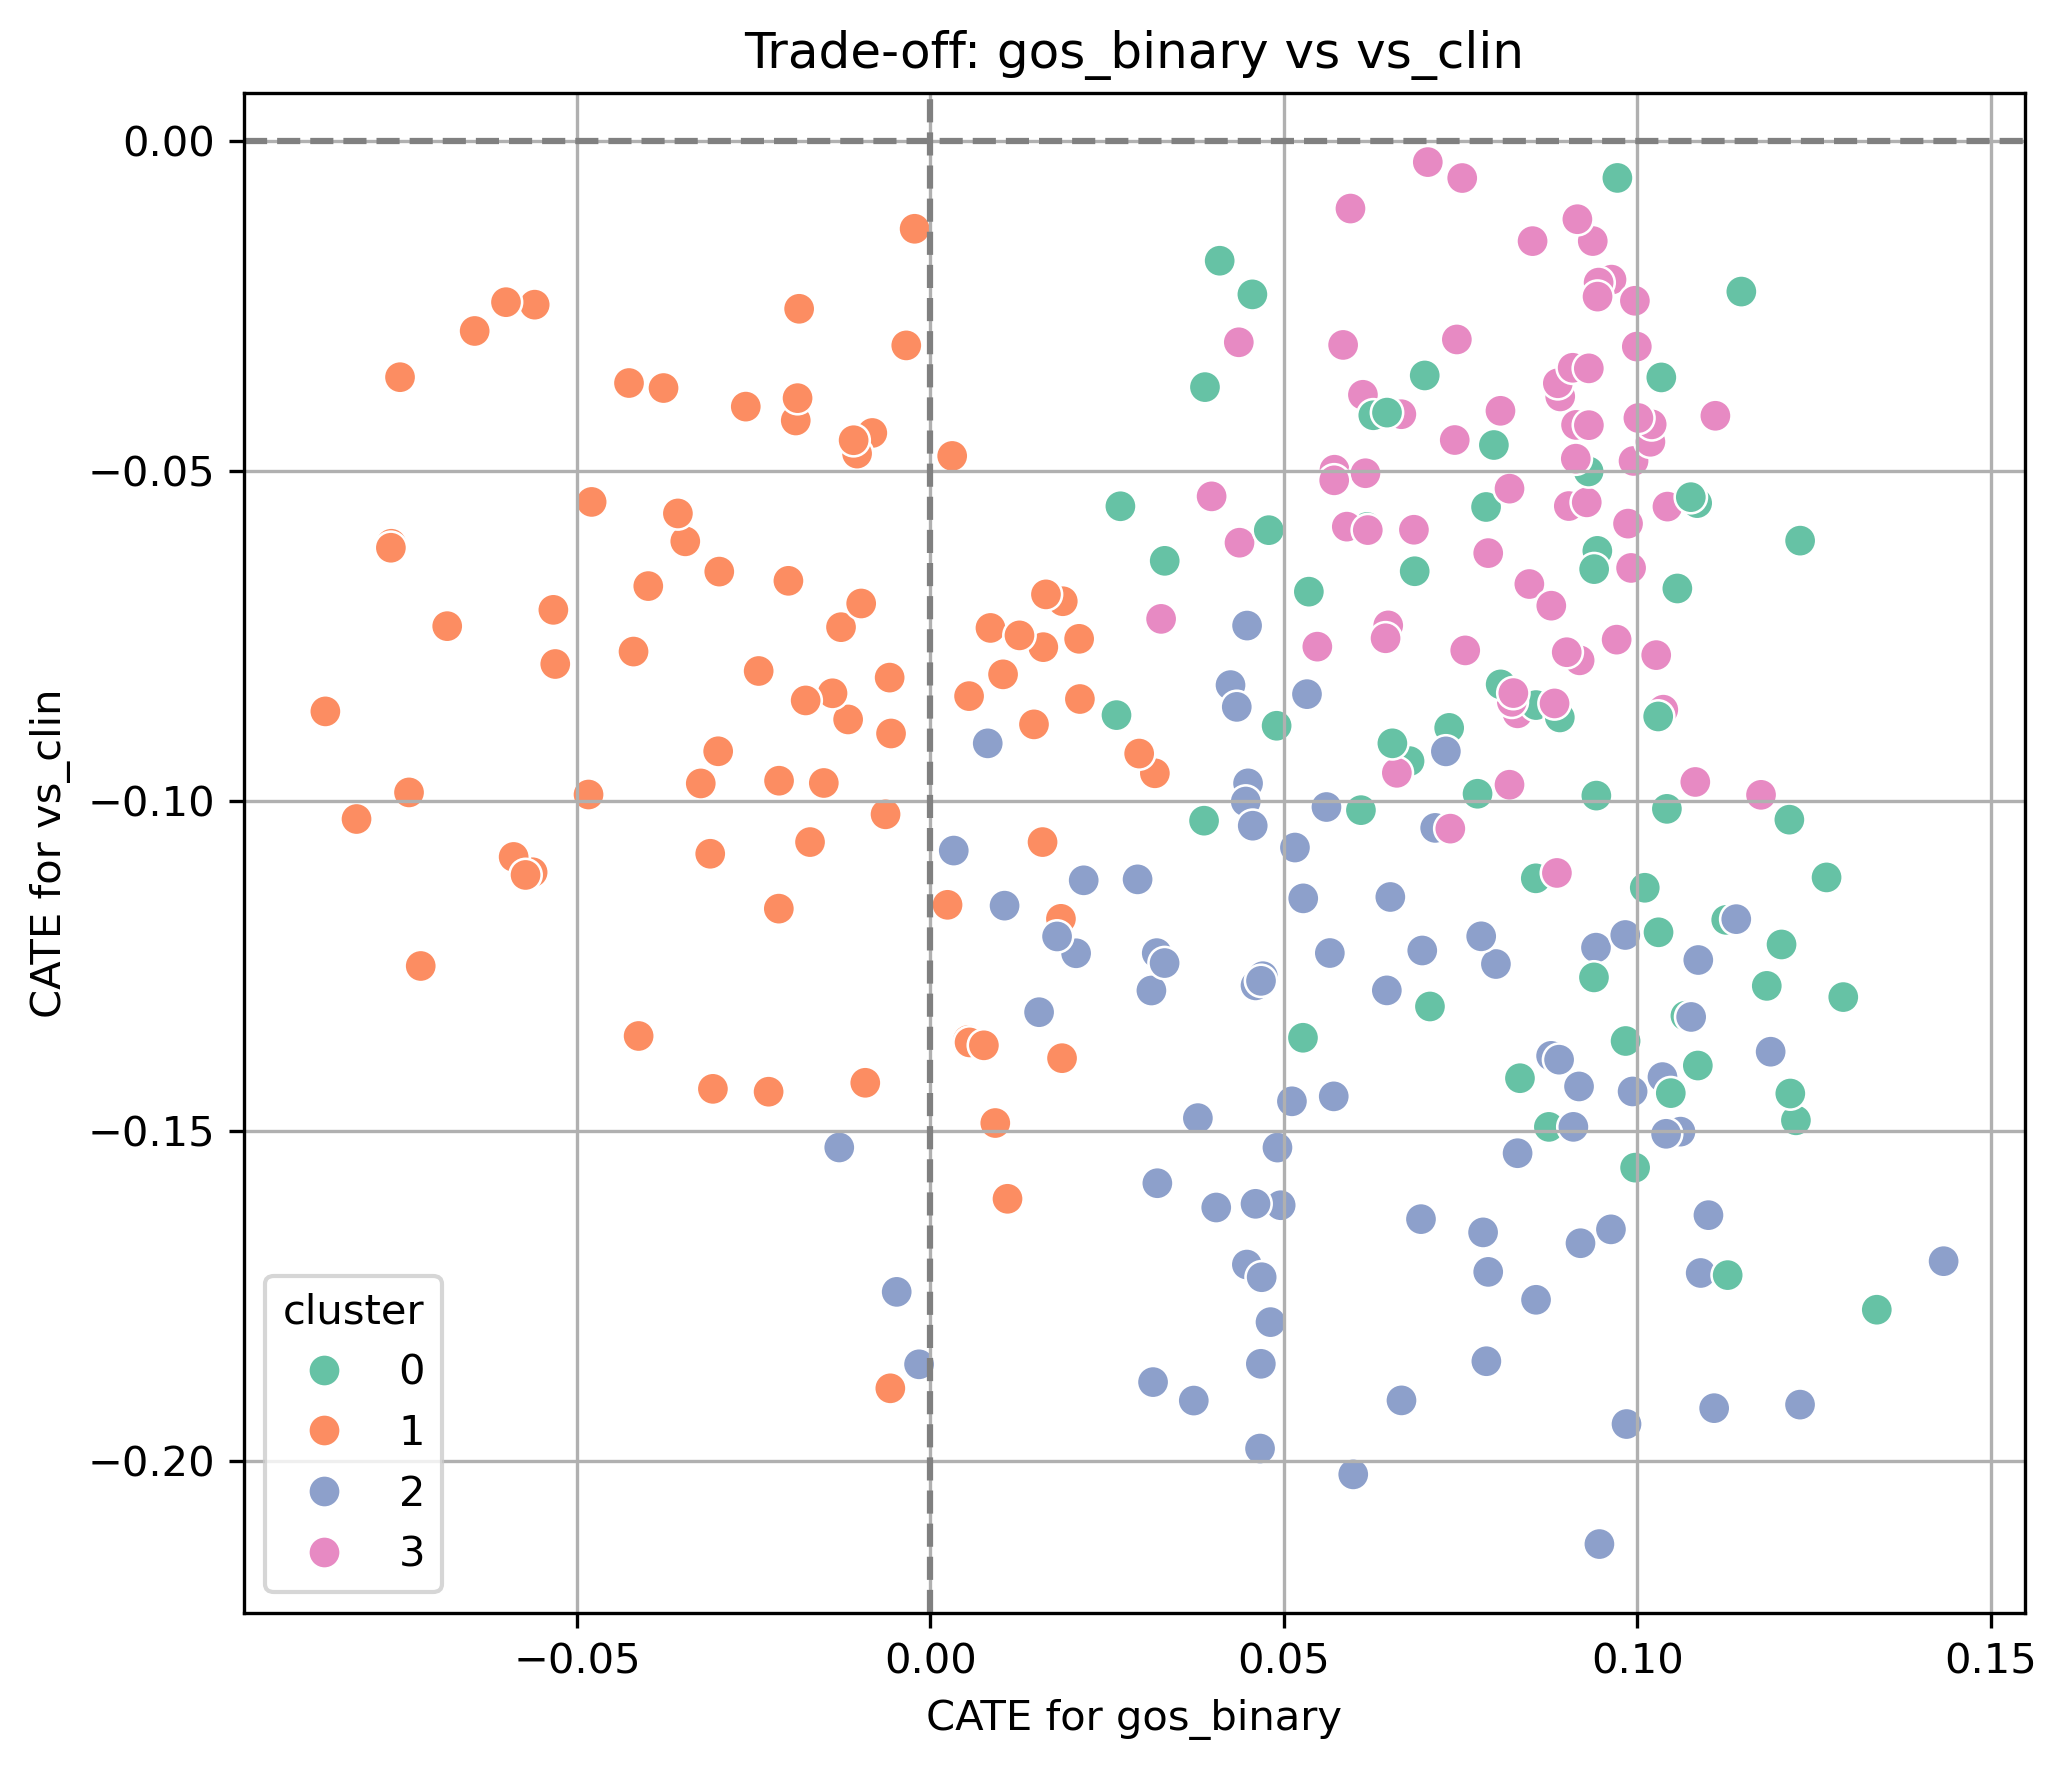

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cate_df = pd.DataFrame(cate_matrix, columns=cate_file_dict.keys())
cate_df['cluster'] = clusters

plot_cate_tradeoff(cate_df, "gos_binary", "vs_clin", clusters=cate_df['cluster'])
  